# KLASIFKASI EMAIL SPAM BAHASA INDONESIA MENGGUNAKAN ALGORITMA SPPORT VECTOR MACHINE


## 1. Import Data & Library

In [ ]:
# Instalasi library pihak ketiga (hanya dijalankan sekali di lingkungan seperti Google Colab)
!pip install Sastrawi     # Untuk pengolahan kata dasar bahasa Indonesia
!pip install wordcloud    # Untuk membuat visualisasi kumpulan kata

# Import library dasar untuk pengolahan data
import pandas as pd      # Untuk mengelola data dalam bentuk tabel (DataFrame)
import numpy as np       # Untuk perhitungan angka dan array
import warnings          # Untuk mengatur peringatan sistem
import re               # Untuk manipulasi teks (Regex)
import string           # Memanipulasi teks

# Mengabaikan pesan peringatan agar tampilan output lebih bersih
warnings.filterwarnings('ignore')

# Import alat pengolahan bahasa Indonesia (Sastrawi)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory           # Untuk mengubah kata berimbuhan ke kata dasar
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory # Untuk menghapus kata umum yang tidak penting

# Import library untuk visualisasi data
import matplotlib.pyplot as plt    # Untuk membuat grafik dasar
import seaborn as sns             # Untuk membuat tampilan grafik lebih cantik
from wordcloud import WordCloud    # Untuk membuat gambar awan kata

# Import alat Machine Learning (Scikit-Learn)
from sklearn.feature_extraction.text import TfidfVectorizer  # Mengubah teks menjadi angka (vektor) berdasarkan bobot kata
from sklearn.svm import LinearSVC                           # Algoritma klasifikasi (Support Vector Machine)
from sklearn.model_selection import StratifiedKFold         # Metode pembagian data untuk pengujian agar adil
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # Indikator penilaian akurasi model
from sklearn.metrics import confusion_matrix, classification_report               # Laporan detail hasil prediksi

# Import alat untuk menyimpan model
import joblib    # Untuk menyimpan model yang sudah dilatih agar bisa dipakai lagi nanti

# Pesan penutup proses persiapan
print("Library sudah siap, lanjut proses...")



Library sudah siap, lanjut proses...


## 2. EDA (Exploratory Data Analysis)

In [ ]:
# Memberi tanda bahwa proses pembacaan data dimulai
print("Mulai dataset...")

# Membaca file CSV menggunakan library Pandas (df singkatan dari DataFrame)
df = pd.read_csv('email_spam_indo_filter.csv')

# Menampilkan jumlah total baris data yang ada di dalam file
print("Total data:", len(df))

# Menampilkan baris data untuk melihat struktur kolom dan isinya
print("\nTampilan Dataset:")
df


Mulai dataset...
Total data: 421

Tampilan Dataset:


,Kategori,Pesan
0,spam,Secara alami tak tertahankan identitas perusah...
1,spam,Fanny Gunslinger Perdagangan Saham adalah Merr...
2,spam,Rumah -rumah baru yang luar biasa menjadi muda...
3,spam,4 Permintaan Khusus Pencetakan Warna Informasi...
4,spam,"Jangan punya uang, dapatkan CD perangkat lunak..."
...,...,...
416,ham,Seminar Zingales FYI! - - - - - - - - - - - - ...
417,ham,PJML 01: Dasar -Dasar - 16 Januari 2001 01/04/...
418,ham,Re: Pembaruan Berlangganan Susan: Vince ingin ...
419,ham,"Pertemuan mingguan Maureen, ini untuk menginga..."


Explore struktur kelas yaitu spam dan ham. Analisis Struktur Data

In [ ]:
# Menampilkan judul dan garis pembatas agar output terlihat rapi
print("DATASET EMAIL SPAM INDONESIA")
print("-" * 40)

# Menampilkan dimensi data (jumlah baris, jumlah kolom)
print("Ukuran data:", df.shape)

# Menampilkan daftar nama kolom yang tersedia dalam file CSV
print("\nKolom yang ada:", df.columns.tolist())

# Mengecek tipe data setiap kolom (misal: object untuk teks, int64 untuk angka)
print("\nTipe data:")
print(df.dtypes)

# Menghitung jumlah data per kategori (Spam vs Ham) sebelum diubah
print("\nLabel awal (Masih berupa teks):")
print(df['Kategori'].value_counts())

# PROSES ENCODING: Mengubah teks menjadi angka: spam jadi 1, ham (bukan spam) jadi 0
df['Kategori'] = df['Kategori'].map({'spam': 1, 'ham': 0})

# Menampilkan hasil perubahan untuk memastikan proses map berhasil
print("\nLabel setelah encoding (Sudah jadi angka):")
print(df['Kategori'].value_counts())


DATASET EMAIL SPAM INDONESIA
----------------------------------------
Ukuran data: (421, 2)

Kolom yang ada: ['Kategori', 'Pesan']

Tipe data:
Kategori    object
Pesan       object
dtype: object

Label awal (Masih berupa teks):
Kategori
ham     277
spam    144
Name: count, dtype: int64

Label setelah encoding (Sudah jadi angka):
Kategori
0    277
1    144
Name: count, dtype: int64


## 3. Data Pra Pemrosesan


**1. Pengecekan Data Kosong (Handle missing Values)**

In [ ]:
# Menampilkan instruksi pengecekan data yang kosong
print("Cek missing values SEBELUM ditangani:\n")

# Menghitung jumlah sel kosong di setiap kolom
# .isnull() mengecek apakah data kosong, .sum() menjumlahkan total yang kosong
print(df.isnull().sum())

# Menghitung persentase data yang kosong
# Rumus: (jumlah kosong / total seluruh data) * 100
print("\nPersentase missing values (%):")
print((df.isnull().sum() / len(df)) * 100)


Cek missing values SEBELUM ditangani:

Kategori    0
Pesan       0
dtype: int64

Persentase missing values (%):
Kategori    0.0
Pesan       0.0
dtype: float64


**2. CLEANING**

*   Menghapus URL
*   Menghapus alamat email
*   Menghapus tag HTML
*   Menghapus tanda baca
*   Menghapus angka
*   Menghapus spasi berlebih

In [ ]:
# Membuat fungsi pembersih teks (Cleaning)
def cleaning_text(text):
    # Jika data kosong (NaN), kembalikan string kosong
    if pd.isna(text):
        return ""

    # Pastikan data dianggap sebagai teks (string)
    text = str(text)

    # Menghapus URL/Link website (http, https, www)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Menghapus alamat email
    text = re.sub(r'\S+@\S+', '', text)

    # Menghapus tag HTML (seperti <br>, <b>, dll)
    text = re.sub(r'<.*?>', '', text)

    # Menghapus angka
    text = re.sub(r'\d+', '', text)

    # Menghapus semua tanda baca (!, @, #, dst)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Menghapus karakter selain huruf (menghapus simbol aneh)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Menghapus huruf berulang yang berlebihan (contoh: 'horeeee' jadi 'horee')
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # Menghapus spasi berlebih di awal, tengah, dan akhir teks
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Menjalankan proses cleaning
print("Mulai cleaning...")
# Membuat kolom baru bernama 'cleaning' hasil dari pemrosesan kolom 'Pesan'
df['cleaning'] = df['Pesan'].apply(cleaning_text)

# Mengatur ulang urutan kolom agar lebih rapi dilihat
df = df[['Kategori', 'Pesan', 'cleaning']]

# Menampilkan  untuk membandingkan Pesan asli vs Hasil cleaning
print("Hasil pembersihan teks:")
df


Mulai cleaning...
Hasil pembersihan teks:


,Kategori,Pesan,cleaning
0,1,Secara alami tak tertahankan identitas perusah...,Secara alami tak tertahankan identitas perusah...
1,1,Fanny Gunslinger Perdagangan Saham adalah Merr...,Fanny Gunslinger Perdagangan Saham adalah Merr...
2,1,Rumah -rumah baru yang luar biasa menjadi muda...,Rumah rumah baru yang luar biasa menjadi mudah...
3,1,4 Permintaan Khusus Pencetakan Warna Informasi...,Permintaan Khusus Pencetakan Warna Informasi T...
4,1,"Jangan punya uang, dapatkan CD perangkat lunak...",Jangan punya uang dapatkan CD perangkat lunak ...
...,...,...,...
416,0,Seminar Zingales FYI! - - - - - - - - - - - - ...,Seminar Zingales FYI Sekolah Pascasarjana Mana...
417,0,PJML 01: Dasar -Dasar - 16 Januari 2001 01/04/...,PJML Dasar Dasar Januari PJM TO Vincent Kamins...
418,0,Re: Pembaruan Berlangganan Susan: Vince ingin ...,Re Pembaruan Berlangganan Susan Vince ingin me...
419,0,"Pertemuan mingguan Maureen, ini untuk menginga...",Pertemuan mingguan Maureen ini untuk mengingat...


**3. Case Folding**

In [ ]:
# Membuat fungsi untuk mengubah teks menjadi huruf kecil semua (Case Folding)
def case_folding(text):
    # Mengecek apakah input adalah teks (string)
    if isinstance(text, str):
        return text.lower() # Mengubah semua huruf menjadi kecil
    # Jika bukan teks (misal data kosong), kembalikan string kosong
    return ""

# Menjalankan fungsi case_folding pada kolom 'cleaning'
# Hasilnya disimpan di kolom baru bernama 'case_folding'
df['case_folding'] = df['cleaning'].apply(case_folding)

# Menampilkan 4 baris pertama untuk melihat perubahannya
print("Hasil Case Folding (Semua huruf menjadi kecil):")
df


Hasil Case Folding (Semua huruf menjadi kecil):


,Kategori,Pesan,cleaning,case_folding
0,1,Secara alami tak tertahankan identitas perusah...,Secara alami tak tertahankan identitas perusah...,secara alami tak tertahankan identitas perusah...
1,1,Fanny Gunslinger Perdagangan Saham adalah Merr...,Fanny Gunslinger Perdagangan Saham adalah Merr...,fanny gunslinger perdagangan saham adalah merr...
2,1,Rumah -rumah baru yang luar biasa menjadi muda...,Rumah rumah baru yang luar biasa menjadi mudah...,rumah rumah baru yang luar biasa menjadi mudah...
3,1,4 Permintaan Khusus Pencetakan Warna Informasi...,Permintaan Khusus Pencetakan Warna Informasi T...,permintaan khusus pencetakan warna informasi t...
4,1,"Jangan punya uang, dapatkan CD perangkat lunak...",Jangan punya uang dapatkan CD perangkat lunak ...,jangan punya uang dapatkan cd perangkat lunak ...
...,...,...,...,...
416,0,Seminar Zingales FYI! - - - - - - - - - - - - ...,Seminar Zingales FYI Sekolah Pascasarjana Mana...,seminar zingales fyi sekolah pascasarjana mana...
417,0,PJML 01: Dasar -Dasar - 16 Januari 2001 01/04/...,PJML Dasar Dasar Januari PJM TO Vincent Kamins...,pjml dasar dasar januari pjm to vincent kamins...
418,0,Re: Pembaruan Berlangganan Susan: Vince ingin ...,Re Pembaruan Berlangganan Susan Vince ingin me...,re pembaruan berlangganan susan vince ingin me...
419,0,"Pertemuan mingguan Maureen, ini untuk menginga...",Pertemuan mingguan Maureen ini untuk mengingat...,pertemuan mingguan maureen ini untuk mengingat...


**4. NORMALISASI**

In [ ]:
# Mengambil kamus normalisasi umum dari sumber eksternal (GitHub)
url = "https://raw.githubusercontent.com/evrintobing17/NormalisasiKata/master/colloquial-indonesian-lexicon.csv"
normalization_data = pd.read_csv(url)

# Mengubah data tersebut menjadi format 'Dictionary' (kunci: kata salah, nilai: kata benar)
normalization_dict = dict(zip(normalization_data['slang'], normalization_data['formal']))

# Menambahkan kamus buatan sendiri (Custom Dictionary) untuk kata-kata yang belum ada
custom_dict = {
    # Bahasa Gaul/Slang
    "bro": "saudara", "gan": "saudara", "sis": "saudara", "nggak": "tidak", "gak": "tidak",
    "ga": "tidak", "g": "tidak", "banget": "sangat", "bgt": "sangat", "gue": "saya",
    "gw": "saya", "lo": "kamu", "lu": "kamu",

    # Bahasa Tidak Baku / Singkatan
    "gmn": "bagaimana", "jg": "juga", "dpt": "dapat", "aja": "saja", "udh": "sudah",
    "tp": "tetapi", "sdh": "sudah", "skrg": "sekarang", "blm": "belum", "dgn": "dengan",
    "utk": "untuk", "krn": "karena", "klo": "kalau", "kalo": "kalau", "msh": "masih",

    # Istilah Khusus & Typo
    "tf": "transfer", "trf": "transfer", "apps": "aplikasi", "trims": "terima kasih",
    "makasih": "terima kasih", "moga": "semoga"
}

# Menggabungkan kamus dari GitHub dengan kamus buatan kita
normalization_dict.update(custom_dict)

# Membuat fungsi untuk mengubah kata tidak baku menjadi baku
def normalize_text(text):
    # Pastikan data ada dan berupa teks
    if not isinstance(text, str) or text.strip() == "":
        return ""

    # Memecah kalimat menjadi kumpulan kata
    words = text.split()

    # Cek setiap kata di kamus. Jika ada, ganti dengan yang formal. Jika tidak, pakai kata aslinya.
    normalized_words = [normalization_dict.get(word, word) for word in words]

    # Gabungkan kembali kumpulan kata menjadi satu kalimat utuh
    return " ".join(normalized_words)

# Eksekusi proses normalisasi
print("Memulai normalisasi...")
df['normalisasi'] = df['case_folding'].apply(normalize_text)
print("Normalisasi selesai!")

# Menata ulang tampilan kolom agar mudah dibandingkan
df = df[['Kategori', 'Pesan', 'cleaning', 'case_folding', 'normalisasi']]

# Menampilkan hasil akhir
df


Memulai normalisasi...
Normalisasi selesai!


,Kategori,Pesan,cleaning,case_folding,normalisasi
0,1,Secara alami tak tertahankan identitas perusah...,Secara alami tak tertahankan identitas perusah...,secara alami tak tertahankan identitas perusah...,secara alami tak tertahankan identitas perusah...
1,1,Fanny Gunslinger Perdagangan Saham adalah Merr...,Fanny Gunslinger Perdagangan Saham adalah Merr...,fanny gunslinger perdagangan saham adalah merr...,fanny gunslinger perdagangan saham adalah merr...
2,1,Rumah -rumah baru yang luar biasa menjadi muda...,Rumah rumah baru yang luar biasa menjadi mudah...,rumah rumah baru yang luar biasa menjadi mudah...,rumah rumah baru yang luar biasa menjadi mudah...
3,1,4 Permintaan Khusus Pencetakan Warna Informasi...,Permintaan Khusus Pencetakan Warna Informasi T...,permintaan khusus pencetakan warna informasi t...,permintaan khusus pencetakan warna informasi t...
4,1,"Jangan punya uang, dapatkan CD perangkat lunak...",Jangan punya uang dapatkan CD perangkat lunak ...,jangan punya uang dapatkan cd perangkat lunak ...,jangan punya uang dapatkan celana dalam perang...
...,...,...,...,...,...
416,0,Seminar Zingales FYI! - - - - - - - - - - - - ...,Seminar Zingales FYI Sekolah Pascasarjana Mana...,seminar zingales fyi sekolah pascasarjana mana...,seminar zingales fyi sekolah pascasarjana mana...
417,0,PJML 01: Dasar -Dasar - 16 Januari 2001 01/04/...,PJML Dasar Dasar Januari PJM TO Vincent Kamins...,pjml dasar dasar januari pjm to vincent kamins...,pjml dasar dasar januari pjm tapi vincent kami...
418,0,Re: Pembaruan Berlangganan Susan: Vince ingin ...,Re Pembaruan Berlangganan Susan Vince ingin me...,re pembaruan berlangganan susan vince ingin me...,re pembaruan berlangganan susan vince ingin me...
419,0,"Pertemuan mingguan Maureen, ini untuk menginga...",Pertemuan mingguan Maureen ini untuk mengingat...,pertemuan mingguan maureen ini untuk mengingat...,pertemuan mingguan maureen ini untuk mengingat...


**5. TOKENISASI**

In [ ]:
# Memberikan informasi bahwa proses pemecahan kalimat dimulai
print("Proses Tokenizing...")

# Melakukan Tokenisasi menggunakan fungsi lambda
# x.split() berfungsi memotong kalimat berdasarkan spasi menjadi sebuah daftar kata (list)
# Contoh: "saya makan" menjadi ["saya", "makan"]
df['tokenisasi'] = df['normalisasi'].apply(lambda x: x.split())

# Menata ulang tampilan kolom untuk melihat perkembangan proses
# Kita tampilkan kolom kategori, normalisasi (sebelum), dan tokenisasi (sesudah)
df_tampil = df[['Kategori', 'normalisasi', 'tokenisasi']]

# Menampilkan 4 baris pertama
df_tampil


Proses Tokenizing...


,Kategori,normalisasi,tokenisasi
0,1,secara alami tak tertahankan identitas perusah...,"[secara, alami, tak, tertahankan, identitas, p..."
1,1,fanny gunslinger perdagangan saham adalah merr...,"[fanny, gunslinger, perdagangan, saham, adalah..."
2,1,rumah rumah baru yang luar biasa menjadi mudah...,"[rumah, rumah, baru, yang, luar, biasa, menjad..."
3,1,permintaan khusus pencetakan warna informasi t...,"[permintaan, khusus, pencetakan, warna, inform..."
4,1,jangan punya uang dapatkan celana dalam perang...,"[jangan, punya, uang, dapatkan, celana, dalam,..."
...,...,...,...
416,0,seminar zingales fyi sekolah pascasarjana mana...,"[seminar, zingales, fyi, sekolah, pascasarjana..."
417,0,pjml dasar dasar januari pjm tapi vincent kami...,"[pjml, dasar, dasar, januari, pjm, tapi, vince..."
418,0,re pembaruan berlangganan susan vince ingin me...,"[re, pembaruan, berlangganan, susan, vince, in..."
419,0,pertemuan mingguan maureen ini untuk mengingat...,"[pertemuan, mingguan, maureen, ini, untuk, men..."


**6. Stopword removal**

In [ ]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Menampilkan status proses
print("Memulai proses Stopword Removal...")

# Menyiapkan daftar kata yang akan dibuang (Stopwords)
# Contoh kata yang dibuang: "yang", "dan", "di", "dari", "untuk"
factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

# Membuat fungsi untuk menyaring kata
def remove_stopwords(tokenisasi):
    # Mengambil kata yang TIDAK ada di dalam daftar stopwords
    return [word for word in tokenisasi if word not in stopwords]

# 4. Menjalankan fungsi pada kolom 'tokenisasi'
# Hasilnya berupa list kata yang sudah bersih dari kata sambung
df['stopword_removal'] = df['tokenisasi'].apply(remove_stopwords)

# Menampilkan hasil perbandingan
# Kita tampilkan kolom kategori, tokenisasi (sebelum), dan stopword_removal (sesudah)
print("Stopword Removal selesai!")
df[['Kategori', 'tokenisasi', 'stopword_removal']]


Memulai proses Stopword Removal...
Stopword Removal selesai!


,Kategori,tokenisasi,stopword_removal
0,1,"[secara, alami, tak, tertahankan, identitas, p...","[alami, tak, tertahankan, identitas, perusahaa..."
1,1,"[fanny, gunslinger, perdagangan, saham, adalah...","[fanny, gunslinger, perdagangan, saham, merril..."
2,1,"[rumah, rumah, baru, yang, luar, biasa, menjad...","[rumah, rumah, baru, luar, biasa, menjadi, mud..."
3,1,"[permintaan, khusus, pencetakan, warna, inform...","[permintaan, khusus, pencetakan, warna, inform..."
4,1,"[jangan, punya, uang, dapatkan, celana, dalam,...","[jangan, punya, uang, dapatkan, celana, perang..."
...,...,...,...
416,0,"[seminar, zingales, fyi, sekolah, pascasarjana...","[seminar, zingales, fyi, sekolah, pascasarjana..."
417,0,"[pjml, dasar, dasar, januari, pjm, tapi, vince...","[pjml, dasar, dasar, januari, pjm, vincent, ka..."
418,0,"[re, pembaruan, berlangganan, susan, vince, in...","[re, pembaruan, berlangganan, susan, vince, me..."
419,0,"[pertemuan, mingguan, maureen, ini, untuk, men...","[pertemuan, mingguan, maureen, mengingatkan, m..."


**7. Stemming**
**Mengambil semua baris dari dataframe**

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Menampilkan status proses
# Catatan: Proses ini mungkin butuh waktu beberapa menit jika data Anda banyak
print("\nMemulai proses Stemming... (Harap tunggu)")

# Inisialisasi Stemmer dari Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Membuat fungsi untuk mengubah kata menjadi kata dasar
# Contoh: "membelikan" -> "beli", "diskonnya" -> "diskon"
def stemming(tokens):
    # Mengubah setiap kata dalam list tokens menjadi kata dasarnya
    return [stemmer.stem(word) for word in tokens]

# Menjalankan fungsi pada kolom hasil stopword removal
df['stemming'] = df['stopword_removal'].apply(stemming)

# Menampilkan hasil akhir pemrosesan teks
print("Stemming selesai!")
df[['Kategori', 'stopword_removal', 'stemming']]



Memulai proses Stemming... (Harap tunggu)
Stemming selesai!


,Kategori,stopword_removal,stemming
0,1,"[alami, tak, tertahankan, identitas, perusahaa...","[alami, tak, tahan, identitas, usaha, sangat, ..."
1,1,"[fanny, gunslinger, perdagangan, saham, merril...","[fanny, gunslinger, dagang, saham, merrill, mu..."
2,1,"[rumah, rumah, baru, luar, biasa, menjadi, mud...","[rumah, rumah, baru, luar, biasa, jadi, mudah,..."
3,1,"[permintaan, khusus, pencetakan, warna, inform...","[minta, khusus, cetak, warna, informasi, tamba..."
4,1,"[jangan, punya, uang, dapatkan, celana, perang...","[jangan, punya, uang, dapat, celana, perangkat..."
...,...,...,...
416,0,"[seminar, zingales, fyi, sekolah, pascasarjana...","[seminar, zingales, fyi, sekolah, pascasarjana..."
417,0,"[pjml, dasar, dasar, januari, pjm, vincent, ka...","[pjml, dasar, dasar, januari, pjm, vincent, ka..."
418,0,"[re, pembaruan, berlangganan, susan, vince, me...","[re, baru, langgan, sus, vince, baru, semua, l..."
419,0,"[pertemuan, mingguan, maureen, mengingatkan, m...","[temu, minggu, maureen, ingat, jadwal, atas, m..."


**8. REMOVE DUPLICATE / FINAL TEKS**


In [ ]:
# Menggabungkan kembali list kata menjadi kalimat utuh (String)
# Kalimat yang tadinya ['beli', 'promo', 'sekarang'] menjadi "beli promo sekarang"
df['final_text'] = df['stemming'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))

# Memastikan tipe data di kolom tersebut adalah teks (string)
df['final_text'] = df['final_text'].astype(str)

# Menghapus baris yang kosong (jika ada pesan yang isinya hilang setelah dibersihkan)
df = df[df['final_text'].str.strip() != ""]

# Menghapus data duplikat (pesan yang sama persis agar tidak mengganggu penilaian model)
df = df.drop_duplicates(subset=['final_text'])

# Mengatur ulang nomor urut data (index) agar rapi kembali dari 0
df = df.reset_index(drop=True)

# Menampilkan 4 baris pertama hasil akhir yang sudah sangat bersih
print("Hasil Final Preprocessing (Siap masuk ke Machine Learning):")
df[['Kategori', 'final_text']].head(15)

Hasil Final Preprocessing (Siap masuk ke Machine Learning):


,Kategori,final_text
0,1,alami tak tahan identitas usaha sangat sulit i...
1,1,fanny gunslinger dagang saham merrill muzo buk...
2,1,rumah rumah baru luar biasa jadi mudah tunjuk ...
3,1,minta khusus cetak warna informasi tambah seka...
4,1,jangan punya uang dapat celana perangkat lunak...
5,1,nnews hebat halo selamat datang medzonline sh ...
6,1,ikut main panas investments security investmen...
7,1,simpan uang beli dapat barang sini coba ciall ...
8,1,kirim bisnis bas rumah orang tata subjek pesan...
9,1,simpan uang beli dapat barang sini coba ciall ...


# 4. Penyeimbangan Data Balancing

In [ ]:
from sklearn.utils import resample

# 1. Menampilkan tanda dimulainya proses penyeimbangan data
print("Proses Data Balancing...")
print("=" * 50)

# 2. Memastikan label kategori berupa teks agar mudah difilter (spam='1', ham='0')
df['Kategori'] = df['Kategori'].astype(str)

# 3. Memisahkan data ke dalam dua kelompok: Spam dan Ham
df_spam = df[df['Kategori'] == '1']
df_ham = df[df['Kategori'] == '0']

# 4. Menampilkan jumlah data asli sebelum diseimbangkan
print("Sebelum balancing:")
print(df['Kategori'].value_counts())

# 5. Proses Resampling: Mengambil sampel sebanyak 50 untuk masing-masing kategori
# Catatan: n_samples disesuaikan agar jumlah spam dan ham menjadi sama (seimbang)
df_spam_bal = resample(df_spam, replace=False, n_samples=50, random_state=42)
df_ham_bal = resample(df_ham, replace=False, n_samples=50, random_state=42)

# 6. Menggabungkan kembali data spam dan ham yang sudah seimbang
df_balanced = pd.concat([df_spam_bal, df_ham_bal])

# 7. Mengacak (Shuffle) urutan data agar posisi spam dan ham tidak berurutan
# frac=1 artinya mengambil 100% data untuk diacak
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# 8. Menampilkan hasil akhir setelah proses penyeimbangan
print("\nSetelah balancing:")
print("Total data baru:", df_balanced.shape)
print(df_balanced['Kategori'].value_counts())


Proses Data Balancing...
Sebelum balancing:
Kategori
0    277
1    144
Name: count, dtype: int64

Setelah balancing:
Total data baru: (100, 9)
Kategori
0    50
1    50
Name: count, dtype: int64


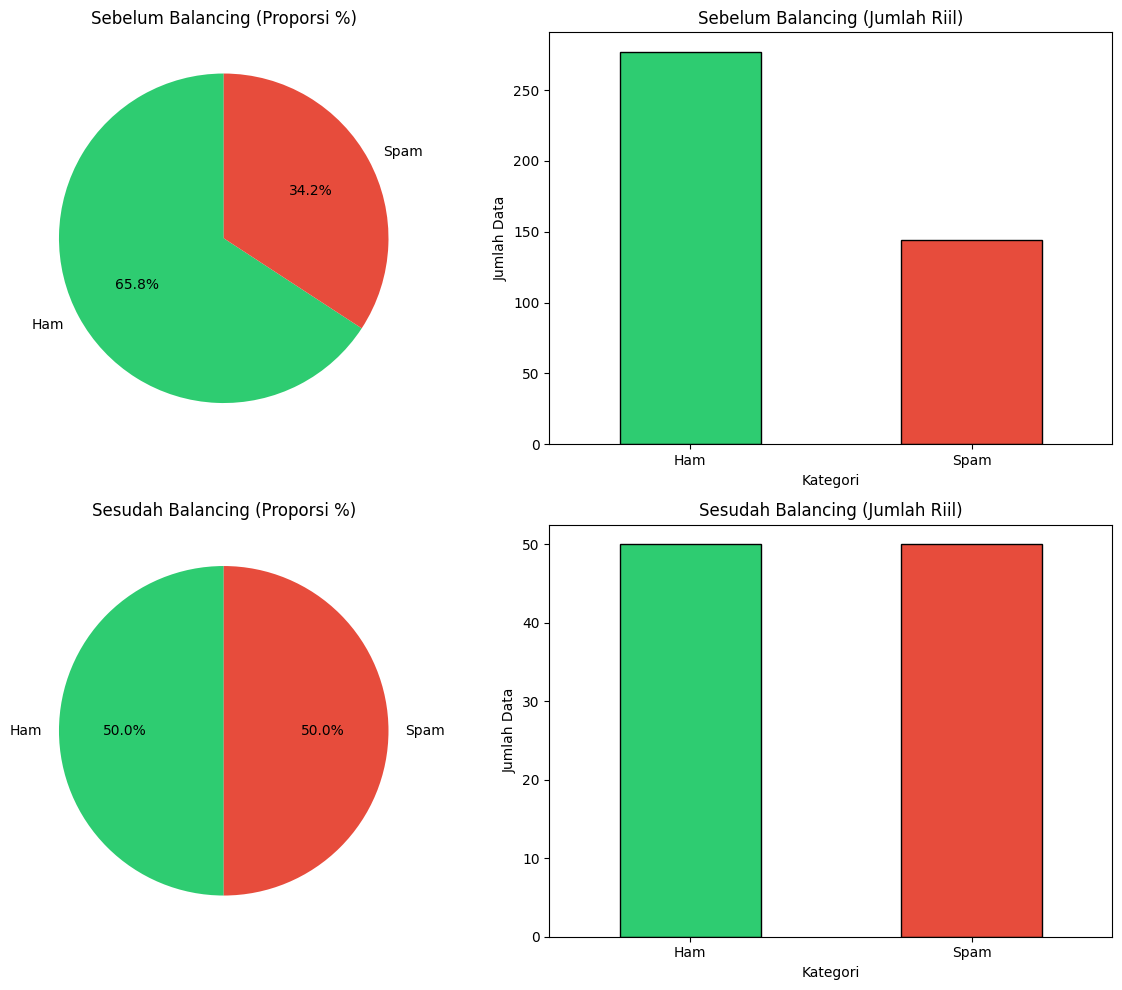

In [ ]:
import matplotlib.pyplot as plt

# Membuat kanvas/bingkai grafik dengan ukuran 2 baris dan 2 kolom
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Konfigurasi warna (Hijau untuk Ham, Merah untuk Spam)
colors = ['#2ecc71', '#e74c3c']
labels = ['Ham', 'Spam']

# --- BAGIAN ATAS: DATA SEBELUM BALANCING ---

# Menghitung jumlah data asli
sizes_before = df['Kategori'].value_counts().sort_index()

# Grafik Lingkaran (Pie Chart) - Kiri Atas
axes[0,0].pie(sizes_before, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Sebelum Balancing (Proporsi %)')

# Grafik Batang (Bar Chart) - Kanan Atas
sizes_before.plot(kind='bar', ax=axes[0,1], color=colors, edgecolor='black')
axes[0,1].set_title('Sebelum Balancing (Jumlah Riil)')
axes[0,1].set_xticklabels(labels, rotation=0) # Mengatur label X agar tidak miring

# --- BAGIAN BAWAH: DATA SESUDAH BALANCING ---

# Menghitung jumlah data yang sudah diseimbangkan
sizes_after = df_balanced['Kategori'].value_counts().sort_index()

# Grafik Lingkaran (Pie Chart) - Kiri Bawah
axes[1,0].pie(sizes_after, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1,0].set_title('Sesudah Balancing (Proporsi %)')

# Grafik Batang (Bar Chart) - Kanan Bawah
sizes_after.plot(kind='bar', ax=axes[1,1], color=colors, edgecolor='black')
axes[1,1].set_title('Sesudah Balancing (Jumlah Riil)')
axes[1,1].set_xticklabels(labels, rotation=0)

# Memberikan label pada sumbu grafik
for ax in [axes[0,1], axes[1,1]]:
    ax.set_xlabel("Kategori")
    ax.set_ylabel("Jumlah Data")

# Mengatur tata letak agar antar grafik tidak saling bertabrakan
plt.tight_layout()

# Menampilkan hasil visualisasi
plt.show()


## 5. Text Vectorization (TF-IDF)

TF-IDF (Term Frequency-Inverse Document Frequency) akan mengubah teks menjadi representasi numerik yang dapat diproses oleh model ML.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# 1. Menampilkan status proses
print("Membuat TF-IDF Vectorizer...")

# 2. Konfigurasi "Penerjemah" (Vectorizer)
# TF-IDF memberikan bobot pada kata: kata yang unik di satu dokumen tapi jarang di dokumen lain diberi bobot tinggi.
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,   # Mengambil maksimal 10.000 kata paling penting
    min_df=1,             # Kata minimal muncul 1 kali
    max_df=0.95,          # Abaikan kata yang muncul di lebih dari 95% data (terlalu umum)
    ngram_range=(1, 2),   # Mengambil kata tunggal (1) dan gabungan dua kata (2) contoh: "menang", "anda menang"
    lowercase=True        # Memastikan semua menjadi huruf kecil
)

# 3. Proses Transformasi (Fit & Transform)
# Mengubah kolom 'normalisasi' menjadi matriks angka (X)
X = tfidf_vectorizer.fit_transform(df_balanced['normalisasi'])

# 4. Menyiapkan Label/Target (y)
# Mengubah kolom 'Kategori' menjadi angka bulat (Integer) 0 atau 1
y = df_balanced['Kategori'].astype(int)

# 5. Menampilkan hasil akhir
print("\nTF-IDF selesai!")
# Shape menunjukkan: (Jumlah baris data, Jumlah fitur/kata unik yang ditemukan)
print("Ukuran Matriks (Shape):", X.shape)


Membuat TF-IDF Vectorizer...

TF-IDF selesai!
Ukuran Matriks (Shape): (100, 10000)


## 6. Pengujian Model (K-Fold Cross Validation)
Manual split

*   Manual split
*   Validasi proporsi
* Klasifikasi




In [ ]:
from sklearn.model_selection import StratifiedKFold
import pandas as pd

# 1. Menampilkan judul proses
print("Pembagian Data dengan 5-Fold Cross Validation...")
print("=" * 50)

# 2. Menyiapkan "Mesin Pemotong" Data (StratifiedKFold)
# n_splits=5 artinya data akan dibagi menjadi 5 bagian/lipatan (fold)
# Stratified memastikan persentase label di setiap bagian tetap seimbang (misal 50:50)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Melakukan perulangan (looping) untuk setiap Fold
for i, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f"\n>>> Fold Ke-{i+1}")

    # Membagi data X (fitur) dan y (label) berdasarkan indeks yang sudah ditentukan
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Menampilkan informasi ukuran data di setiap fold
    print(f"Data Latih (Training): {X_train.shape[0]} baris")
    print(f"Data Uji (Testing)  : {X_test.shape[0]} baris")

    # Menampilkan distribusi label untuk memastikan keseimbangan
    print("Distribusi Label di Data Latih:")
    print(pd.Series(y_train).value_counts().to_string())
    print("Distribusi Label di Data Uji:")
    print(pd.Series(y_test).value_counts().to_string())
    print("-" * 30)

print("\nPembagian data selesai. Siap masuk ke tahap Training Model!")


Pembagian Data dengan 5-Fold Cross Validation...

>>> Fold Ke-1
Data Latih (Training): 80 baris
Data Uji (Testing)  : 20 baris
Distribusi Label di Data Latih:
Kategori
0    40
1    40
Distribusi Label di Data Uji:
Kategori
1    10
0    10
------------------------------

>>> Fold Ke-2
Data Latih (Training): 80 baris
Data Uji (Testing)  : 20 baris
Distribusi Label di Data Latih:
Kategori
0    40
1    40
Distribusi Label di Data Uji:
Kategori
0    10
1    10
------------------------------

>>> Fold Ke-3
Data Latih (Training): 80 baris
Data Uji (Testing)  : 20 baris
Distribusi Label di Data Latih:
Kategori
0    40
1    40
Distribusi Label di Data Uji:
Kategori
1    10
0    10
------------------------------

>>> Fold Ke-4
Data Latih (Training): 80 baris
Data Uji (Testing)  : 20 baris
Distribusi Label di Data Latih:
Kategori
0    40
1    40
Distribusi Label di Data Uji:
Kategori
0    10
1    10
------------------------------

>>> Fold Ke-5
Data Latih (Training): 80 baris
Data Uji (Testing)  

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC
import numpy as np

# 1. Menampilkan judul evaluasi
print("\nEvaluasi 5-Fold Cross Validation dengan SVM...")
print("=" * 50)

# 2. Inisialisasi Model LinearSVC
# LinearSVC sangat direkomendasikan untuk data teks dengan banyak fitur (hasil TF-IDF)
model = LinearSVC(random_state=42)

# 3. Menghitung akurasi secara otomatis untuk setiap Fold
# cv=kf menggunakan pembagian data yang sudah kita buat sebelumnya
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

# 4. Menampilkan hasil akurasi untuk setiap percobaan (Fold)
print("\nHasil akurasi tiap fold:")
for i, score in enumerate(cv_scores):
    # .4f artinya menampilkan 4 angka di belakang koma (desimal)
    print(f"Fold {i+1}: {score:.4f} ({score*100:.2f}%)")

# 5. Menghitung dan menampilkan performa rata-rata model
mean_accuracy = np.mean(cv_scores)
print("-" * 30)
print(f"Rata-rata akurasi total: {mean_accuracy:.4f} ({mean_accuracy*100:.2f}%)")
print("=" * 50)



Evaluasi 5-Fold Cross Validation dengan SVM...

Hasil akurasi tiap fold:
Fold 1: 1.0000 (100.00%)
Fold 2: 0.9500 (95.00%)
Fold 3: 0.9000 (90.00%)
Fold 4: 0.9000 (90.00%)
Fold 5: 1.0000 (100.00%)
------------------------------
Rata-rata akurasi total: 0.9500 (95.00%)


In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

# 1. Menghasilkan prediksi untuk seluruh data menggunakan metode Cross Validation
# y_pred adalah hasil tebakan model terhadap seluruh data
y_pred = cross_val_predict(model, X, y, cv=kf)

# 2. Menampilkan laporan klasifikasi yang mendetail
print("\n=== LAPORAN KLASIFIKASI (Classification Report) ===")
print(classification_report(y, y_pred, target_names=['Ham (Bukan Spam)', 'Spam']))



=== LAPORAN KLASIFIKASI (Classification Report) ===
                  precision    recall  f1-score   support

Ham (Bukan Spam)       0.98      0.92      0.95        50
            Spam       0.92      0.98      0.95        50

        accuracy                           0.95       100
       macro avg       0.95      0.95      0.95       100
    weighted avg       0.95      0.95      0.95       100



## 7. Model Evaluation

In [ ]:
import pandas as pd
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import LinearSVC

# 1. Judul Laporan
print("EVALUASI AKHIR MODEL SVM (LinearSVC)")
print("=" * 60)

# 2. Inisialisasi Model SVM (Linear Support Vector Classification)
# Model ini sangat efektif untuk klasifikasi teks berskala besar
model = LinearSVC(random_state=42)

# 3. Melakukan Prediksi dengan Cross Validation (5-Fold)
# Membagi data menjadi 5 bagian secara bergantian untuk melatih dan menguji model
y_pred = cross_val_predict(model, X, y, cv=5)

# 4. Menghitung Skor Metrik
# pos_label=1 artinya kita fokus pada kemampuan model mendeteksi SPAM
accuracy  = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, pos_label=1)
recall    = recall_score(y, y_pred, pos_label=1)
f1        = f1_score(y, y_pred, pos_label=1)

# 5. Membuat Tabel Ringkasan Performa
svm_result = pd.DataFrame({
    'Metrik Evaluasi': ['Accuracy', 'Precision (Spam)', 'Recall (Spam)', 'F1-Score (Spam)'],
    'Skor Model': [accuracy, precision, recall, f1]
})

# 6. Menampilkan Tabel dengan format 4 desimal
print("Ringkasan Skor:")
display(svm_result.style.format({'Skor Model': '{:.4f}'}).hide(axis='index'))

# 7. Menampilkan Laporan Detail (Classification Report)
print("\nLaporan Detail Klasifikasi:")
# Target names membantu kita membaca mana yang Ham (0) dan mana yang Spam (1)
print(classification_report(y, y_pred, target_names=['Ham (Bukan Spam)', 'Spam']))


## 8. Simpan Model yang Telah Dilatih

Simpan model terbaik beserta vectorizer ke folder `models/` dengan format yang rapi dan timestamp.

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

print("🔧 Memulai Proses Perbaikan Model (Tuning)...")
print("=" * 50)

# 1. Menggunakan Pipeline
# Ini menggabungkan Vectorizer dan Model dalam satu kesatuan agar tidak terjadi kesalahan data
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ('classifier', LinearSVC(random_state=42, max_iter=2000))
])

# 2. Mencari Parameter Terbaik (Hyperparameter Tuning)
# Kita mencoba beberapa nilai 'C' (kekuatan regulasi) untuk mencari yang paling akurat
param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__loss': ['hinge', 'squared_hinge']
}

# 3. Menjalankan Pencarian Otomatis
# Menggunakan 5-Fold untuk memastikan hasil terbaik
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(df_balanced['normalisasi'], y)

# 4. Menampilkan Hasil Perbaikan
print(f"✅ Parameter Terbaik: {grid_search.best_params_}")
print(f"✅ Akurasi Terbaik  : {grid_search.best_score_:.4f}")

# 5. Menyimpan Model yang Sudah Diperbaiki
best_model = grid_search.best_estimator_
joblib.dump(best_model, 'models/best_svm_pipeline.joblib')
print("\nModel yang telah diperbaiki berhasil disimpan!")


🔧 Memulai Proses Perbaikan Model (Tuning)...
✅ Parameter Terbaik: {'classifier__C': 0.1, 'classifier__loss': 'squared_hinge'}
✅ Akurasi Terbaik  : 0.9600

Model yang telah diperbaiki berhasil disimpan!


# 9. Test Model


In [ ]:
import joblib

# 1. Load Model dan Vectorizer yang sudah disimpan tadi
# Pastikan nama file sesuai dengan yang ada di folder 'models' kamu
model_path = model_filename # Mengambil path dari proses save sebelumnya
vect_path = vectorizer_filename

loaded_model = joblib.load(model_path)
loaded_vect = joblib.load(vect_path)

# 2. Fungsi Prediksi Mandiri
def prediksi_spam(teks_baru):
    # a. Proses Preprocessing Singkat (Case Folding & Cleaning minimal)
    teks_bersih = teks_baru.lower()

    # b. Transformasi teks menjadi angka menggunakan vectorizer yang sudah di-load
    teks_vektor = loaded_vect.transform([teks_bersih])

    # c. Prediksi menggunakan model
    prediksi = loaded_model.predict(teks_vektor)

    # d. Hasil
    hasil = "SPAM" if prediksi[0] == 1 else "HAM (Bukan Spam)"
    return hasil

# 3. Uji Coba Langsung
print("--- TEST PREDIKSI PESAN ---")
pesan_test = [
    "Selamat! Anda mendapatkan hadiah 10 juta dari Shopee. Klik link bit.ly/hadiah-anda",
    "Halo bro, besok jadi kumpul di kafe jam 7 malam gak?",
    "Pinjaman online tanpa jaminan, bunga rendah, proses cepat. Balas YA untuk info lanjut",
    "Pagi bu, saya ijin telat masuk kelas karena ada urusan keluarga"
]

for p in pesan_test:
    hasil = prediksi_spam(p)
    print(f"Pesan: {p}")
    print(f"Hasil: {hasil}\n" + "-"*30)


--- TEST PREDIKSI PESAN ---
Pesan: Selamat! Anda mendapatkan hadiah 10 juta dari Shopee. Klik link bit.ly/hadiah-anda
Hasil: SPAM
------------------------------
Pesan: Halo bro, besok jadi kumpul di kafe jam 7 malam gak?
Hasil: SPAM
------------------------------
Pesan: Pinjaman online tanpa jaminan, bunga rendah, proses cepat. Balas YA untuk info lanjut
Hasil: SPAM
------------------------------
Pesan: Pagi bu, saya ijin telat masuk kelas karena ada urusan keluarga
Hasil: HAM (Bukan Spam)
------------------------------
